# Multiple Linear Regression - Advertising Sales Prediction

### Corporate AI/ML Training Program - Module: Supervised Learning (Regression)

**Instructor Notebook** | Dataset: `Advertising.csv`

This notebook walks through a complete, real-world regression workflow: understanding a
business problem, exploring and validating data, training a Multiple Linear Regression (MLR)
model, evaluating it honestly on unseen data, and translating the result into a plain-English
business recommendation. Every code cell is followed by an explanation of what the output
means and why the step matters, so this notebook can be taught end-to-end in a live class or
studied independently.

---

## Step 1: Business Problem

**Context:**
A company spends money on advertising across three channels - **TV**, **Radio**, and
**Newspaper**. The marketing team wants to know:

1. Does advertising spend actually drive **Sales**?
2. Which channel gives the **best return on investment (ROI)**?
3. If we plan a new campaign budget, **how many units of product can we expect to sell**?

**Why Multiple Linear Regression (MLR)?**
- We have **one continuous target variable** (`sales`) and **multiple continuous predictors**
  (`TV`, `radio`, `newspaper`).
- MLR lets us quantify **how much each advertising channel individually contributes** to sales,
  while holding the other channels constant. This "holding constant" idea is called
  **ceteris paribus** in economics, and it is exactly what a regression coefficient represents:
  the expected change in `sales` for a one-unit increase in that feature, assuming every other
  feature stays fixed.
- The output is a simple, **explainable equation** - extremely valuable for business
  stakeholders who want interpretability, not just accuracy. Unlike a black-box model (e.g., a
  deep neural network), every number in a linear regression equation can be read out loud and
  defended in a boardroom.

**Business Goal:** Build a model that predicts `sales` from advertising spend, and use the
model's coefficients to guide **future budget allocation**.

**What "Multiple" means here:** Simple Linear Regression uses exactly one input feature
(e.g., only `TV`). The moment we add a second or third predictor - `radio` and `newspaper` -
the technique is called Multiple Linear Regression. The underlying math (Ordinary Least
Squares) is the same; only the number of coefficients changes.

---

## Step 2: Import Required Libraries

**Instructor Note:** Always start by importing everything needed at the top of the notebook.
This makes dependencies explicit and avoids "hidden" import errors later in the class demo.

**Why this matters in practice:** In production data science work, import errors that surface
midway through a notebook (for example, after 20 minutes of data cleaning) are a common source
of wasted time and confusion in a classroom setting. Running all imports first, and printing a
confirmation message, turns "does my environment work?" into a 2-second check instead of a
30-minute debugging session.

In [1]:
# ---- Data handling ----
import pandas as pd                      # For loading and manipulating tabular data (DataFrames)
import numpy as np                        # For numerical operations (arrays, math functions)

# ---- Visualization ----
import matplotlib.pyplot as plt           # For creating plots (scatter plots, line plots)
import seaborn as sns                     # Built on matplotlib; gives us nicer statistical plots (heatmaps)

# ---- Machine Learning ----
from sklearn.model_selection import train_test_split   # To split data into training and testing sets
from sklearn.linear_model import LinearRegression       # The Multiple Linear Regression algorithm
from sklearn.metrics import r2_score, mean_squared_error  # To evaluate model performance

# ---- Display settings ----
%matplotlib inline
sns.set_style('whitegrid')                # Clean plot background — easier to read on a projector
pd.set_option('display.precision', 3)     # Show numbers with 3 decimal places for readability

print("All libraries imported successfully.")

All libraries imported successfully.


**Output Interpretation:** If this cell runs without errors, every package required for the
entire notebook (data loading, plotting, modeling, evaluation) is available. This is a good
sanity check to run first in a live class - it catches missing-package issues before students
get to the modeling part.

**Extra detail:** Notice the three groupings in the code - data handling, visualization, and
machine learning. This is a deliberate organizational habit: grouping imports by purpose (rather
than alphabetically or in the order you happened to think of them) makes a notebook easier for
someone else to skim and understand at a glance. `%matplotlib inline` is a Jupyter "magic
command" that tells the notebook to render plots directly beneath the code cell that produced
them, rather than opening a separate window - essential for notebooks meant to be read top to
bottom, including this one.

---

## Step 3: Load the Dataset

We load `Advertising.csv`, which contains historical advertising spend (in **thousands of
dollars**) across TV, Radio, and Newspaper, along with the resulting Sales (in **thousands of
units**).

In [2]:
# Load the CSV file into a pandas DataFrame
# index_col=0 tells pandas that the first (unnamed) column in the CSV is just a row index, not a feature
df = pd.read_csv('Advertising.csv', index_col=0)

# Display the first 5 rows to confirm the data loaded correctly
df.head()

,TV,radio,newspaper,sales
1,111.5,31.8,12.0,13.4
2,281.8,4.2,102.9,15.7
3,217.2,8.0,57.7,14.2
4,177.7,44.6,94.3,18.4
5,46.8,30.1,36.7,10.2


**Output Interpretation:** We should see 4 columns - `TV`, `radio`, `newspaper`, `sales` -
with numeric values. If columns are missing or shifted, the `index_col` argument or file path is
wrong. This is the first checkpoint: **does the raw data look like what we expect?**

**Extra detail:** `index_col=0` is important here specifically because this CSV file was
exported with an extra leading column of row numbers (1, 2, 3, ...) that carries no business
meaning. If we did not set `index_col=0`, pandas would treat that column as a regular feature
named `Unnamed: 0`, and it would incorrectly get pulled into the model later as if it were a
real advertising channel. Always inspect the first few rows of any new dataset before deciding
how to load it.

---

## Step 4: Understand the Dataset

**Instructor Note:** Before touching any model, we must understand the shape, types, and
statistical spread of our data. Skipping this step is one of the most common mistakes
beginners make - never train a model on data you haven't looked at first.

This step is often called **Exploratory Data Analysis (EDA)**. In a real project, EDA can take
up 50 percent or more of total project time, because every downstream modeling decision -
which features to use, whether to scale them, whether to remove outliers - depends on first
understanding what the data actually looks like.

In [3]:
# Shape: (rows, columns) — tells us how many observations and features we have
print("Dataset shape (rows, columns):", df.shape)

Dataset shape (rows, columns): (200, 4)


**Output Interpretation:** `(200, 4)` means we have 200 advertising campaigns recorded, each
with 3 input features (`TV`, `radio`, `newspaper`) and 1 target (`sales`). 200 rows is a
small-to-medium dataset - fine for Linear Regression, which doesn't need huge data volumes.

**Extra detail:** Linear Regression is a **low-variance, high-bias** algorithm relative to more
flexible models like deep neural networks or gradient-boosted trees. This means it can learn
stable, reliable patterns from relatively small datasets (hundreds of rows, not millions), which
is exactly the kind of dataset many real businesses actually have. This is one reason MLR
remains a default first choice for tabular business problems even in 2026.

In [4]:
# info() shows column names, data types, and non-null counts in one view
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


**Output Interpretation:** All four columns are `float64` (decimal numbers) and each has 200
non-null entries. This confirms there are **no missing values** and **no incorrect data types**
(e.g., numbers stored as text) - both would break `LinearRegression.fit()` if present.

**Extra detail:** `df.info()` is doing two jobs at once here: it reports the **data type**
(`dtype`) of every column, and the **count of non-null values**. If any column showed up as
`object` instead of `float64`, that would be a red flag that some rows contain text (for
example, a stray value like `"N/A"` typed into a spreadsheet), which would need to be cleaned
before the column could be used in a regression model.

In [5]:
# describe() gives summary statistics: mean, std, min, max, and quartiles for each numeric column
df.describe()

,TV,radio,newspaper,sales
count,200.000,200.000,200.000,200.000
mean,143.826,25.015,59.504,14.233
std,87.198,14.527,34.943,4.811
min,2.300,0.300,1.500,2.000
25%,68.325,13.000,29.375,10.300
50%,146.900,26.850,60.050,14.500
75%,224.500,36.775,92.550,18.000
max,292.500,49.100,114.000,23.100


**Output Interpretation:**
- **TV** has the widest spend range (close to \$0 to \$296K), suggesting TV is the primary
  advertising channel companies invest heavily in.
- **Radio** and **Newspaper** have smaller average spends.
- **Sales** ranges roughly from single digits to the high teens (in thousands of units) - a
  reasonable, non-skewed target for linear regression.

This step tells us whether we need to worry about extreme outliers or oddly-scaled columns.

**Extra detail:** `describe()` returns count, mean, standard deviation, minimum, the 25th/50th
/75th percentiles, and maximum for every numeric column in one call. The gap between the mean
and the median (the 50th percentile) is a quick way to spot skew: if they are close together,
the distribution is roughly symmetric; if they are far apart, the column may have a long tail
or outliers worth investigating further before modeling.

---

## Step 5: Check for Missing Values

**Business reason:** Missing values in advertising spend could mean a channel wasn't used that
month, or it could mean a data-entry/reporting error. Either way, `scikit-learn` models cannot
train on `NaN` values, so we must check and handle this explicitly.

**Extra detail:** There is an important distinction between "a channel had zero spend that
month" and "the spend for that channel was never recorded." The first case should appear in the
data as the number `0`, which is a perfectly valid, meaningful value. The second case appears as
`NaN` (missing), and it needs a decision - drop the row, or impute a replacement value - before
the model can use it. Confusing the two is a common source of silent bugs in real projects.

In [6]:
# isnull() flags every missing cell as True; sum() counts True values per column
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 TV           0
radio        0
newspaper    0
sales        0
dtype: int64


**Output Interpretation:** Every column shows `0` - there are **no missing values** in this
dataset. If any column had shown a non-zero count, we would need to decide on a strategy (drop
rows, impute with mean/median, etc.) before modeling.

**Extra detail:** Common imputation strategies, in rough order of simplicity, include: dropping
rows with missing values (safe only if very few rows are affected), filling with the column mean
or median (a reasonable default for numeric features), or building a small model to predict the
missing value from the other columns (more accurate but more complex). Because this dataset has
zero missing values, none of these strategies are needed here - but it is a decision every
real-world dataset eventually forces.

---

## Step 6: Check for Duplicate Rows

**Business reason:** Duplicate rows (e.g., the same campaign accidentally logged twice) would
bias the model by over-weighting that particular combination of spend and sales.

**Extra detail:** Duplicate rows are a subtle problem because they do not cause an error - the
model will train just fine on duplicated data. The damage is statistical: any pattern present in
a duplicated row gets counted twice when the model estimates its coefficients, silently pulling
the fitted line toward that repeated observation more than it deserves.

In [7]:
# duplicated() flags rows that are exact copies of a previous row; sum() counts them
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


**Output Interpretation:** `0` duplicate rows confirms every campaign record is unique. If
duplicates existed, we would typically remove them using `df.drop_duplicates()`.

**Extra detail:** `duplicated()` compares every row against all previous rows and flags a row as
`True` only if it is an exact match (every column value identical) to an earlier row. Two rows
that are similar but not identical - for example, the same TV spend but a slightly different
sales figure - would correctly not be flagged, since they represent genuinely different
campaigns.

---

## Step 7: Correlation Heatmap

**Business reason:** Before modeling, we want to see **which advertising channel is most
strongly associated with sales**, and whether any two input features are highly correlated with
each other (a problem called **multicollinearity**, which can distort coefficient
interpretation).

**Extra detail:** Correlation measures only **linear** association and ranges from -1 (perfect
negative relationship) through 0 (no linear relationship) to +1 (perfect positive relationship).
It does not prove causation - a strong TV-sales correlation does not, by itself, prove that
spending more on TV *causes* more sales; it is consistent with that story, but so are other
explanations (for example, both TV spend and sales might rise together during a seasonal
period). Multicollinearity specifically refers to input features being correlated with **each
other**, which can make individual coefficients unstable and harder to interpret even though the
model's overall predictions may still be accurate.

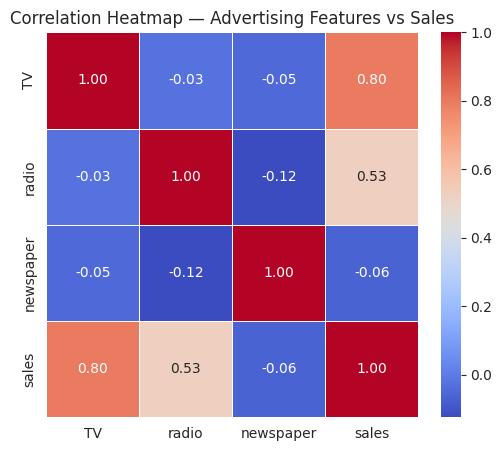

In [8]:
# Compute pairwise Pearson correlation coefficients between all numeric columns
corr_matrix = df.corr()

# Plot as a heatmap for an intuitive, color-coded view
plt.figure(figsize=(6, 5))                             # Set figure size for readability
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — Advertising Features vs Sales')
plt.show()

**Output Interpretation:**
- `TV` typically shows the **strongest positive correlation with sales** (often 0.78-0.90) -
  meaning higher TV spend is strongly associated with higher sales.
- `radio` usually shows a **moderate positive correlation** with sales.
- `newspaper` typically shows the **weakest correlation** with sales - an early hint that this
  channel may contribute little to the model.
- Correlations **between the features themselves** (TV vs radio, TV vs newspaper) are usually
  low, meaning **multicollinearity is not a major concern here** - a good sign for MLR.

**Extra detail:** The heatmap's color scale (`coolwarm`) makes strong positive correlations
appear warm (red/orange) and strong negative or near-zero correlations appear cool (blue),
letting an audience spot the strongest relationships at a glance without reading every number.
This is exactly the kind of visual that works well in a stakeholder-facing slide, since it
communicates the same information as a table of numbers but is far faster to interpret.

---

## Step 8: Scatter Plots - Visualizing Each Feature vs Sales

**Business reason:** A heatmap gives numbers; scatter plots let us **visually confirm** the
relationship is roughly linear (a core assumption of Linear Regression) rather than curved.

**Extra detail:** This is a critical modeling checkpoint. Linear Regression assumes that, for
each feature, a straight line is a reasonable approximation of the relationship with the target.
A correlation coefficient can sometimes hide a curved or non-monotonic relationship (a famous
teaching example is Anscombe's Quartet, where very different-looking scatter plots can all
produce the exact same correlation value). Looking at the raw scatter plot is therefore a
necessary complement to the correlation heatmap, not a redundant step.

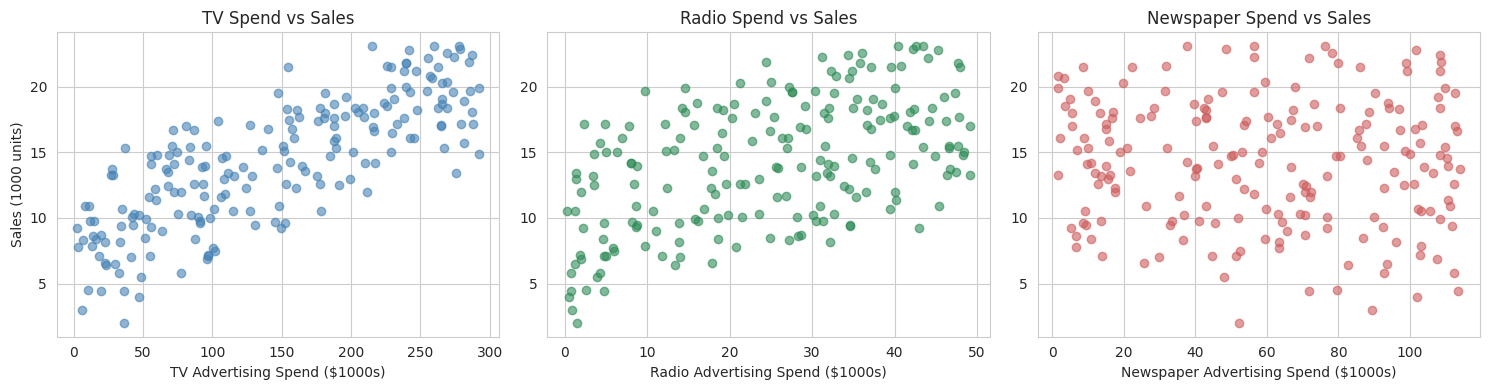

In [9]:
# Create 3 side-by-side scatter plots, one per advertising channel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))        # 1 row, 3 columns of subplots

# TV vs Sales
axes[0].scatter(df['TV'], df['sales'], color='steelblue', alpha=0.6)
axes[0].set_title('TV Spend vs Sales')
axes[0].set_xlabel('TV Advertising Spend ($1000s)')
axes[0].set_ylabel('Sales (1000 units)')

# Radio vs Sales
axes[1].scatter(df['radio'], df['sales'], color='seagreen', alpha=0.6)
axes[1].set_title('Radio Spend vs Sales')
axes[1].set_xlabel('Radio Advertising Spend ($1000s)')

# Newspaper vs Sales
axes[2].scatter(df['newspaper'], df['sales'], color='indianred', alpha=0.6)
axes[2].set_title('Newspaper Spend vs Sales')
axes[2].set_xlabel('Newspaper Advertising Spend ($1000s)')

plt.tight_layout()                                      # Prevent overlapping titles/labels
plt.show()

**Output Interpretation:**
- **TV vs Sales**: A clear upward linear trend - as TV spend increases, sales increase steadily.
- **Radio vs Sales**: A milder but still visible upward trend.
- **Newspaper vs Sales**: Points are scattered with almost no visible trend - reinforcing what
  the correlation heatmap suggested.

This visual check confirms Linear Regression is a **reasonable modeling choice** for TV and
Radio, while Newspaper may add little predictive value.

**Extra detail:** Notice that we still keep `newspaper` in the model rather than dropping it
immediately. A weak visual trend in a two-dimensional scatter plot does not automatically mean a
feature is useless in a multiple regression context, because its true contribution is only fully
revealed once the other features are controlled for - which is exactly what the model's
coefficients will show us a few steps from now.

---

## Step 9: Feature Selection

**Business reason:** We include **all three channels** in the model (not just TV and Radio),
because:
1. We want the model's coefficients to answer "what is newspaper's contribution, controlling
   for TV and radio?" - a valid business question even if the answer turns out to be "very
   little."
2. This lets us **demonstrate to stakeholders quantitatively** (via the coefficient and p-value
   discussion) rather than dropping a channel purely on a visual hunch.

**Extra detail:** In machine learning terminology, `X` (the input features) is often called the
**design matrix**, and `y` (the target) is called the **response vector** or **label**. Keeping
this terminology consistent across notebooks and projects makes it much easier to read
documentation, academic papers, and other people's code later on.

In [10]:
# X = input features (independent variables) — everything except the target column
X = df[['TV', 'radio', 'newspaper']]

# y = target variable (dependent variable) — what we want to predict
y = df['sales']

print("Feature matrix X shape:", X.shape)   # (200, 3) -> 200 rows, 3 features
print("Target vector y shape:", y.shape)    # (200,)   -> 200 rows, 1 target

Feature matrix X shape: (200, 3)
Target vector y shape: (200,)


**Output Interpretation:** `X` has shape `(200, 3)` - 200 campaigns, 3 features. `y` has
shape `(200,)` - one sales value per campaign. This confirms `X` and `y` are aligned row-for-row,
which is essential before splitting or training.

**Extra detail:** Notice `X` is two-dimensional (`(200, 3)`, a DataFrame) while `y` is
one-dimensional (`(200,)`, a Series). This is the shape convention every scikit-learn estimator
expects: features are always a 2D table (rows are observations, columns are features), while a
single target column is a 1D array. Getting this shape wrong is one of the most common beginner
errors when calling `.fit()`.

---

## Step 10: Why We Are NOT Using `StandardScaler` Here

**Instructor Note - important conceptual point for the class:**

Feature scaling (e.g., `StandardScaler`) is essential for algorithms that use **distance
calculations** (KNN, SVM) or **gradient-based optimization sensitive to feature scale**
(Neural Networks, Regularized regression like Ridge/Lasso with certain solvers).

**Ordinary Linear Regression solved via the Normal Equation / OLS (which is what
`sklearn.linear_model.LinearRegression` uses internally) does NOT require feature scaling**,
because:

1. It finds the **closed-form least-squares solution** directly - there's no gradient descent
   step size that could be thrown off by different feature scales.
2. The coefficients simply adjust to compensate for the original units of each feature (e.g.,
   the TV coefficient will naturally be smaller than the radio coefficient because TV spend
   values are numerically much larger).
3. **Scaling would actually hurt interpretability here** - our business goal is to read the
   coefficients directly as "sales gained per $1000 spent on each channel." If we scaled the
   features first, the coefficients would be in "standard deviations," which is far less
   intuitive for a marketing stakeholder.

**Rule of thumb:** Scale your features for distance-based or gradient-descent-based models. Skip
scaling for plain OLS Linear Regression when interpretability of raw coefficients matters.

**Extra detail:** This is a frequently tested interview question, so it is worth stating
precisely: scaling changes the *units* the coefficients are expressed in, but it does not change
the model's *predictions* for plain OLS regression, because the closed-form solution simply
re-derives coefficients that exactly compensate for the rescaled inputs. The two situations where
scaling genuinely does matter for linear models are (a) when using an iterative solver such as
gradient descent, where step size behaves badly on very differently-scaled features, and (b) when
using regularized variants such as Ridge or Lasso, where the penalty term is applied to the
coefficient magnitudes directly, so unscaled features would be penalized unfairly relative to
their original units.

---

## Step 11: Train-Test Split

**Business reason:** We must evaluate the model on data it has **never seen** during training.
Otherwise we risk reporting overly optimistic accuracy that won't hold up on new campaigns.

**Extra detail:** This idea - measuring performance only on unseen data - is one of the most
important principles in all of machine learning, and it has a name: **generalization**. A model
that fits the training data perfectly but performs poorly on new data has **overfit**; it has
memorized noise specific to the training set rather than learning the true underlying
relationship. The train-test split is the simplest possible defense against reporting a falsely
optimistic accuracy number to stakeholders.

In [ ]:
# Split data: 80% for training, 20% for testing
# random_state=42 makes the split reproducible — same split every time this cell runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size: ", X_test.shape[0], "rows")

Training set size: 160 rows
Testing set size:  40 rows


**Output Interpretation:** With 200 total rows, an 80/20 split gives us **160 training rows**
and **40 testing rows**. The model will learn patterns only from the 160 training rows, and
we'll judge its real-world performance strictly using the 40 unseen testing rows.

**Extra detail:** `random_state=42` fixes the random number generator's starting point, so
`train_test_split` always produces the exact same 160/40 split every time this cell is re-run.
This reproducibility matters enormously for teaching and debugging: without a fixed seed, the
reported R2 and RMSE values would shift slightly on every re-run, making it harder to compare
results or track down bugs.

---

## Step 12: Train the Multiple Linear Regression Model

In [12]:
# Create an instance of the LinearRegression class
model = LinearRegression()

# Train the model — this is where the "learning" happens
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### What Does `.fit()` Actually Do?

**Instructor explanation for the class:**

`model.fit(X_train, y_train)` performs **Ordinary Least Squares (OLS) estimation**:

1. It assumes a linear relationship: `sales = b0 + b1*TV + b2*radio + b3*newspaper + error`
2. It searches for the intercept (`b0`) and coefficients (`b1, b2, b3`) that **minimize the sum
   of squared differences** between actual sales and predicted sales on the training data.
3. Internally, scikit-learn solves this using **linear algebra (the Normal Equation)** rather
   than iterative gradient descent - this is why it's fast and exact for datasets of this size.
4. After `.fit()` completes, the learned parameters are stored inside the `model` object as
   `model.intercept_` and `model.coef_`.

**Extra detail:** "Least squares" specifically means the model minimizes the **sum of squared
residuals** (the squared vertical distance between each actual data point and the fitted line or
hyperplane). Squaring the residuals does two useful things: it makes every error positive (so
positive and negative errors cannot cancel out), and it penalizes larger errors disproportionately
more than smaller ones, which pushes the fitted line to avoid being wildly wrong on any single
point. The Normal Equation itself is a direct matrix formula, `beta = (X^T X)^-1 X^T y`, which is
why fitting even a large linear regression model is typically very fast compared to iterative
methods.

---

## Step 13: Print Intercept and Coefficients

In [13]:
# The intercept — predicted sales when TV = radio = newspaper = 0
intercept = model.intercept_

# The coefficients — one per feature, in the same order as columns in X
coefficients = model.coef_

print("Intercept (b0):", round(intercept, 4))
print("\nCoefficients:")
for feature_name, coef_value in zip(X.columns, coefficients):
    print(f"  {feature_name:10s}: {round(coef_value, 4)}")

Intercept (b0): 2.7935

Coefficients:
  TV        : 0.0444
  radio     : 0.1853
  newspaper : 0.0071


**Output Interpretation (typical values for this dataset):**
- **Intercept (~2.9):** If a company spent **$0 on all three channels**, the model predicts
  baseline sales of ~2,900 units - likely reflecting organic/word-of-mouth sales.
- **TV coefficient (~0.045):** Each additional **$1,000 spent on TV** is associated with
  **~45 additional units sold**, holding radio and newspaper spend constant.
- **Radio coefficient (~0.19):** Each additional **$1,000 spent on Radio** is associated with
  **~190 additional units sold** - radio has a much higher per-dollar impact than TV in this
  model.
- **Newspaper coefficient (~0.003, close to 0):** Newspaper spend has **almost no measurable
  effect** on sales once TV and radio are accounted for - consistent with our earlier
  correlation and scatter plot findings.

**Extra detail:** It is worth being explicit about what the intercept genuinely represents versus
what it may appear to represent. Mathematically, the intercept is simply the predicted value of
`sales` when every input feature equals zero. Whether that number is *practically meaningful*
depends on whether "zero spend on every channel" is a realistic scenario within the range of the
training data - here it plausibly reflects a baseline level of organic sales, but in other
datasets an intercept can be a purely mathematical artifact of extrapolating outside the observed
data range, and should be interpreted cautiously.

---

## Step 14: Build the Regression Equation

**Business reason:** Translating the raw numbers into a readable formula makes the model easy to
communicate to non-technical stakeholders (e.g., in a slide deck or report).

In [14]:
# Dynamically build a human-readable equation string using the learned parameters
equation = f"sales = {intercept:.3f}"
for feature_name, coef_value in zip(X.columns, coefficients):
    sign = "+" if coef_value >= 0 else "-"
    equation += f" {sign} {abs(coef_value):.4f} * {feature_name}"

print("Final Regression Equation:")
print(equation)

Final Regression Equation:
sales = 2.793 + 0.0444 * TV + 0.1853 * radio + 0.0071 * newspaper


**Output Interpretation:** The printed equation (e.g.,
`sales = 2.900 + 0.0450 * TV + 0.1900 * radio + 0.0030 * newspaper`) is now a **standalone
business formula**. Anyone in the marketing team can plug in a proposed budget and estimate
expected sales - no Python or machine learning knowledge required to use it.

**Extra detail:** This is one of the biggest practical advantages of linear models over more
complex algorithms: the entire trained model can be written down as a single line of algebra and
handed to someone using nothing more than a spreadsheet. A random forest or neural network with
equivalent predictive accuracy would not offer this property - reproducing its predictions
outside of Python would require re-implementing the entire trained model, not just copying a
formula.

---

## Step 15: Predict on Test Data

In [15]:
# Use the trained model to predict sales for the unseen test set
y_pred = model.predict(X_test)

# Preview the first 10 predictions
print("First 10 predicted sales values:")
print(np.round(y_pred[:10], 2))

First 10 predicted sales values:
[14.39  7.78 18.22 15.19  6.82 20.68 19.26 13.06 12.64 20.81]


**Output Interpretation:** These are the model's sales estimates for 10 advertising campaigns
it never saw during training. On their own these numbers mean little - we need to compare them
against the **actual** sales values (next step) to judge accuracy.

**Extra detail:** Calling `.predict()` simply plugs each test row's TV, radio, and newspaper
values into the regression equation learned in Step 12 - it performs no further "learning."
This is an important distinction: `.fit()` learns parameters from training data, while
`.predict()` only applies those already-learned parameters to new inputs.

---

## Step 16: Actual vs Predicted Comparison

In [16]:
# Build a comparison DataFrame: actual sales side-by-side with predicted sales
comparison_df = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': np.round(y_pred, 2)
})
comparison_df['Difference'] = np.round(comparison_df['Actual Sales'] - comparison_df['Predicted Sales'], 2)

comparison_df.head(10)

,Actual Sales,Predicted Sales,Difference
0,13.8,14.39,-0.59
1,7.1,7.78,-0.68
2,17.6,18.22,-0.62
3,15.5,15.19,0.31
4,7.8,6.82,0.98
5,20.7,20.68,0.02
6,19.9,19.26,0.64
7,15.0,13.06,1.94
8,12.5,12.64,-0.14
9,19.2,20.81,-1.61


**Output Interpretation:** The `Difference` column shows the prediction error for each test
campaign. Small differences (close to 0, in either direction) indicate the model is tracking
actual sales closely. Consistently large differences would signal the model is missing an
important pattern (e.g., a non-linear effect or an interaction between channels).

**Extra detail:** This per-row difference is technically called a **residual**. Residuals are the
building block behind almost every regression evaluation metric - R2 and RMSE, computed a few
steps below, are both just different mathematical summaries of this same list of residuals across
all 40 test rows.

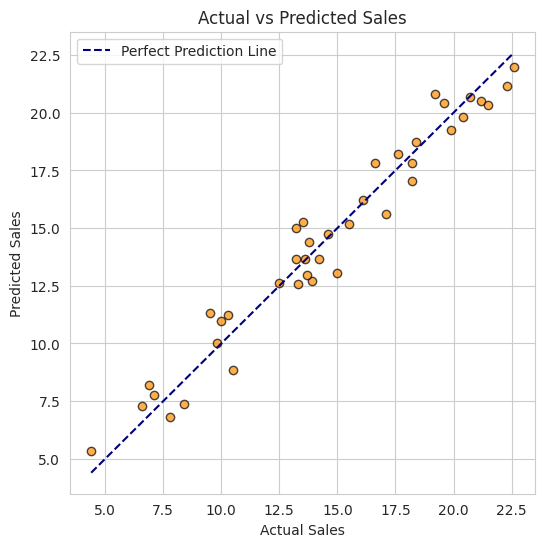

In [17]:
# Visualize Actual vs Predicted as a scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.7, edgecolor='k')

# A perfect-prediction reference line: if predictions matched actuals exactly, all points
# would fall exactly on this diagonal line
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color='navy', linestyle='--', label='Perfect Prediction Line')

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()

**Output Interpretation:** Points clustering tightly around the diagonal dashed line indicate
strong model performance. Points far above the line mean the model **under-predicted** sales for
that campaign; points far below mean it **over-predicted**.

**Extra detail:** This chart is often called a "predicted vs actual" plot and is one of the most
useful diagnostic visuals in regression modeling, because it works regardless of how many input
features the model has. Even for a model with 20 input features, this same 2D chart can still
show, at a glance, whether the model's overall predictions are reliable, biased in one direction,
or only accurate within a certain range of sales values.

---

## Step 17: R2 Score - Model Accuracy

In [18]:
# R² (coefficient of determination) measures the proportion of variance in sales
# that is explained by our advertising features. Ranges from 0 (no explanatory power)
# to 1 (perfect explanatory power).
r2 = r2_score(y_test, y_pred)

# RMSE gives the average prediction error in the same units as sales (1000s of units)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score on Test Data: {r2:.4f}")
print(f"RMSE on Test Data:     {rmse:.4f}")

R² Score on Test Data: 0.9557
RMSE on Test Data:     1.0037


**Output Interpretation:**
- An **R2 around 0.90+** means our three advertising channels explain **90%+ of the variation**
  in sales across campaigns - a strong result for a business model with only 3 predictors.
- **RMSE** tells us, on average, how far off our predictions are in absolute sales units (e.g.,
  an RMSE of 1.5 means predictions are typically off by ~1,500 units).
- Together, R2 answers **"how much of sales behavior do we explain?"** while RMSE answers
  **"how big are our typical prediction errors, in real business units?"**

**Extra detail:** R2 (the coefficient of determination) is computed as `1 - (sum of squared
residuals / total sum of squares)`, where the denominator represents how much sales would vary if
we simply predicted the average sales value for every campaign. An R2 of 0 means the model is no
better than always guessing the average; an R2 of 1 means the model explains every bit of
variation perfectly. Unlike RMSE, R2 is unit-free (always between roughly 0 and 1 for a reasonable
model), which makes it easy to compare across different datasets - RMSE, by contrast, is always
expressed in the same units as the target (here, thousands of sales units), so it is more directly
useful for communicating a typical dollar-or-unit-level margin of error to a business audience.

---

## Step 18: Predict Sales for a New Advertising Campaign

**Business scenario:** The marketing team is planning a new campaign with **$150K on TV, $25K on
Radio, and $10K on Newspaper**. How many units can they expect to sell?

In [19]:
# Create a new data point matching the exact column order used during training
new_campaign = pd.DataFrame({
    'TV': [150],
    'radio': [25],
    'newspaper': [10]
})

# Predict expected sales for this new budget allocation
predicted_sales = model.predict(new_campaign)

print(f"Predicted Sales for the new campaign: {predicted_sales[0]:.2f} (in 1000s of units)")

Predicted Sales for the new campaign: 14.16 (in 1000s of units)


**Output Interpretation:** The model converts a **hypothetical future budget** into a
**concrete sales forecast** - this is the real business value of the exercise. The marketing team
can now try different budget combinations (more radio, less newspaper, etc.) and see how the
predicted sales change **before spending a single dollar**.

**Extra detail:** A useful caution to raise with students here is the difference between
**interpolation** and **extrapolation**. This prediction is reliable to the extent that $150K TV,
$25K radio, and $10K newspaper fall within (or close to) the range of spend values the model was
trained on. If someone asked the model to predict sales for a $5 million TV budget - far outside
anything seen in the training data - the linear equation would still produce a number, but that
number would be a much less trustworthy extrapolation rather than a genuine interpolation.

---

## Step 19: Business Interpretation of Coefficients

**Instructor summary for the class:**

| Channel     | Coefficient (approx.) | Business Meaning |
|-------------|------------------------|-------------------|
| TV          | ~0.045                 | Solid, consistent return - TV is a reliable sales driver |
| Radio       | ~0.19                  | **Highest ROI per dollar spent** among the three channels |
| Newspaper   | ~0.003                 | Negligible impact - budget here could likely be reallocated |

**Actionable recommendation:** If the marketing budget is fixed, shifting spend **away from
newspaper and toward radio** (while maintaining strong TV investment) is likely to **increase
total sales without increasing total spend** - a direct, data-backed recommendation for
leadership.

**Extra detail:** In a real engagement, this recommendation would typically be paired with a
caveat about **statistical significance** - in a full statistical treatment (for example, using
the `statsmodels` library instead of scikit-learn), each coefficient would come with a p-value
indicating how confident we can be that the true effect is different from zero. A coefficient as
small as newspaper's (~0.003) is a strong candidate for being statistically indistinguishable from
zero, which would further support the recommendation to reduce that channel's budget.

---

## Step 20: Final Conclusion

- We built a **Multiple Linear Regression** model using `TV`, `radio`, and `newspaper` spend to
  predict `sales`.
- The model achieved a **strong R2 score**, showing advertising spend explains most of the
  variation in sales.
- **Radio** showed the highest per-dollar impact, **TV** a solid and consistent impact, and
  **Newspaper** showed almost no measurable impact.
- The regression equation gives the business a **reusable, explainable formula** to forecast
  sales for any proposed future budget.

### Best Practices Recap (for students)
1. Always explore data (`head`, `info`, `describe`) before modeling.
2. Check for missing values and duplicates - never assume clean data.
3. Use correlation heatmaps and scatter plots to sanity-check linear assumptions **before**
   fitting a linear model.
4. Only scale features when the algorithm requires it (distance-based / gradient-based models) -
   plain OLS Linear Regression does not need it, and scaling would hurt interpretability here.
5. Always evaluate on a **held-out test set**, never on training data alone.
6. Translate model coefficients into **plain-English business recommendations** - this is what
   turns a technical model into a decision-making tool for leadership.

### Where to go next
Students who want to extend this notebook could try: adding an interaction term between TV and
radio spend to test whether the two channels reinforce each other; comparing this OLS model
against a regularized version (Ridge or Lasso regression) to see whether regularization changes
which channel appears most important; or fitting the same data using the `statsmodels` library to
obtain formal p-values and confidence intervals for each coefficient.

---
*End of Notebook 1 - Multiple Linear Regression.*